<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet5/Tugas%20Praktikum%20(JS5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Pilih salah satu dataset nyata dari sklearn.datasets (misalnya iris dataset atau digits dataset).

In [1]:
# aku memakai iris
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

target_names = iris.target_names

# Tampilkan informasi dataset
print(f"Jumlah sampel: {X.shape[0]}")
print(f"Jumlah fitur : {X.shape[1]}")
print(f"Nama kelas   : {list(target_names)}")

Jumlah sampel: 150
Jumlah fitur : 4
Nama kelas   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


2. Lakukan clustering dengan HDBSCAN

In [3]:
import numpy as np
from sklearn.cluster import HDBSCAN

# 2. Inisialisasi dan fit HDBSCAN
# Parameter min_cluster_size=10 menentukan batas minimum anggota sebuah cluster
hdb = HDBSCAN(min_cluster_size=10, min_samples=5)
labels = hdb.fit_predict(X)

print("Proses clustering dengan HDBSCAN selesai.")

Proses clustering dengan HDBSCAN selesai.


3. A Menampilkan jumlah cluster

In [21]:
import numpy as np

# Menghitung jumlah cluster (tidak menghitung label -1) dan titik noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(f"Jumlah cluster yang terbentuk : {n_clusters}")

Jumlah cluster yang terbentuk : 2


3. B Banyaknya Noise

In [22]:
import numpy as np

# Menghitung titik data yang dianggap noise (berlabel -1)
n_noise = np.sum(labels == -1)

print(f"Banyaknya noise (-1): {n_noise}")

Banyaknya noise (-1): 0


3. C Visualisasi Hasil Clustering (Reduksi PCA)

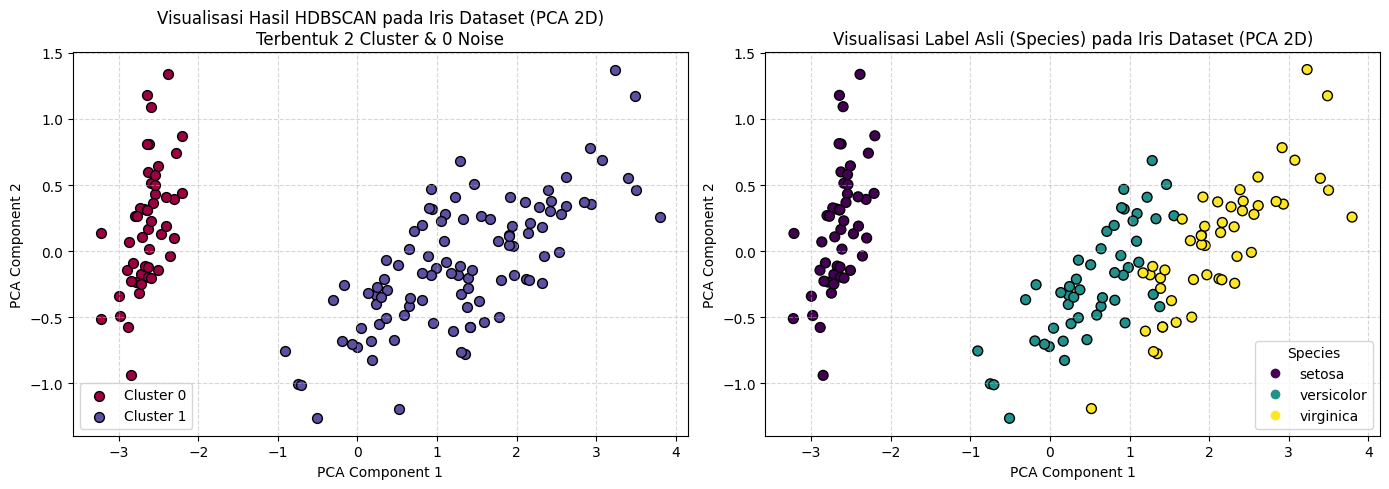

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 3c. Visualisasi Perbandingan (HDBSCAN vs Label Asli)

# Reduksi dimensi dengan PCA ke 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gambar 1 (Kiri): Hasil Clustering HDBSCAN ---
unique_labels = set(labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Warna hitam untuk noise
        marker = 'x'
        label_name = f'Noise (-1): {n_noise}'
    else:
        marker = 'o'
        label_name = f'Cluster {k}'

    class_mask = (labels == k)
    axes[0].scatter(
        X_pca[class_mask, 0],
        X_pca[class_mask, 1],
        c=[col],
        marker=marker,
        edgecolors='k' if k != -1 else None,
        s=50,
        label=label_name
    )

axes[0].set_title(f"Visualisasi Hasil HDBSCAN pada Iris Dataset (PCA 2D)\nTerbentuk {n_clusters} Cluster & {n_noise} Noise")
axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Gambar 2 (Kanan): Label Asli Dataset (Ground Truth) ---
scatter = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    edgecolors='k',
    s=50
)

axes[1].set_title("Visualisasi Label Asli (Species) pada Iris Dataset (PCA 2D)")
axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

# Menambahkan legend nama spesies asli
handles, _ = scatter.legend_elements()
axes[1].legend(handles, target_names, title="Species")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Tabel perbandingan kelas asli vs cluster HDBSCAN
df_res = pd.DataFrame({'Kelas Asli': [target_names[i] for i in y], 'Cluster HDBSCAN': labels})
print("Tabel Distribusi Kelas Asli vs Cluster HDBSCAN:")
print(pd.crosstab(df_res['Kelas Asli'], df_res['Cluster HDBSCAN']))

# Evaluasi metrik kuantitatif
ari = adjusted_rand_score(y, labels)
nmi = normalized_mutual_info_score(y, labels)
print(f"\nAdjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalized Mutual Info    : {nmi:.4f}")

Tabel Distribusi Kelas Asli vs Cluster HDBSCAN:
Cluster HDBSCAN   0   1
Kelas Asli             
setosa           50   0
versicolor        0  50
virginica         0  50

Adjusted Rand Index (ARI) : 0.5681
Normalized Mutual Info    : 0.7337


4. Buat analisis singkat: apakah hasil clustering HDBSCAN sesuai dengan label asli dataset tersebut?

Jawab :

Hasil clustering HDBSCAN ini udah cukup sesuai sama data aslinya, walau jumlah kelompok yang terbentuk cuma 2 dari yang harusnya 3 kelas. Bunga Setosa bisa terpisah sempurna di Cluster 0 karena posisinya paling jauh dari jenis lainnya. Sementara buat Versicolor dan Virginica, keduanya digabungin jadi satu di Cluster 1 gara-gara titik datanya terlalu nempel dan padat tanpa ada jeda kosong di antaranya. Jadi, meskipun jumlah clusternya gak sama persis sama label asli, hasilnya tetep masuk akal dan akurat secara cara kerja HDBSCAN.